# Initial Exploratory Data Analysis

This notebook performs the initial EDA on the ISIC 2019 skin lesion dataset. We examine class distributions, visualize samples from each class, and understand the dataset characteristics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import json
from collections import Counter

In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"

with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)

In [3]:
IMAGES_DIR = RAW_DATA_DIR / "ISIC_2019_Training_Input"
labels_path = DATA_DIR / "labels_with_class.csv"

df = pd.read_csv(labels_path)
print(f"Loaded {len(df)} samples")


Loaded 25331 samples


In [4]:
df.head()

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,class_label
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL


In [5]:
class_counts = df["class_label"].value_counts().sort_index()
print("Class Distribution:")
print(class_counts)
print(f"\nTotal samples: {class_counts.sum()}")

Class Distribution:
class_label
AK        867
BCC      3323
BKL      2624
DF        239
MEL      4522
NV      12875
SCC       628
VASC      253
Name: count, dtype: int64

Total samples: 25331


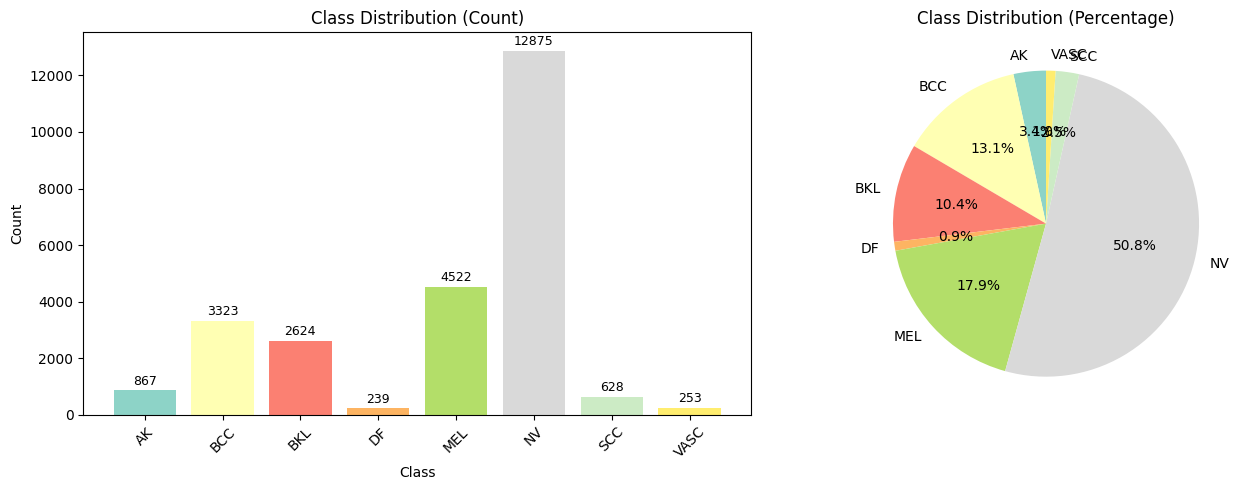

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))

axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution (Count)")
axes[0].tick_params(axis="x", rotation=45)

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, str(v), ha="center", fontsize=9)

class_percentages = (class_counts / class_counts.sum()) * 100
axes[1].pie(class_percentages, labels=class_counts.index, autopct="%1.1f%%", 
            colors=colors, startangle=90)
axes[1].set_title("Class Distribution (Percentage)")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The class distribution shows severe imbalance:
- NV (Melanocytic Nevus) dominates with ~50% of samples
- MEL (Melanoma) has ~17%, the second largest class
- DF (Dermatofibroma) and VASC (Vascular Lesion) have the fewest samples (<1% each)

This imbalance ratio of approximately 50:1 between largest and smallest classes will significantly impact model training and requires mitigation strategies.

In [7]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Majority class: {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"Minority class: {class_counts.idxmin()} ({class_counts.min()} samples)")

Imbalance ratio (max/min): 53.87
Majority class: NV (12875 samples)
Minority class: DF (239 samples)


In [8]:
def load_sample_images(df, class_label, images_dir, n_samples=3):
    """Load n random samples for a given class."""
    class_df = df[df["class_label"] == class_label]
    samples = class_df.sample(n=min(n_samples, len(class_df)), random_state=42)
    
    images = []
    for _, row in samples.iterrows():
        img_path = images_dir / f"{row['image']}.jpg"
        if img_path.exists():
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append((img, row["image"]))
    return images

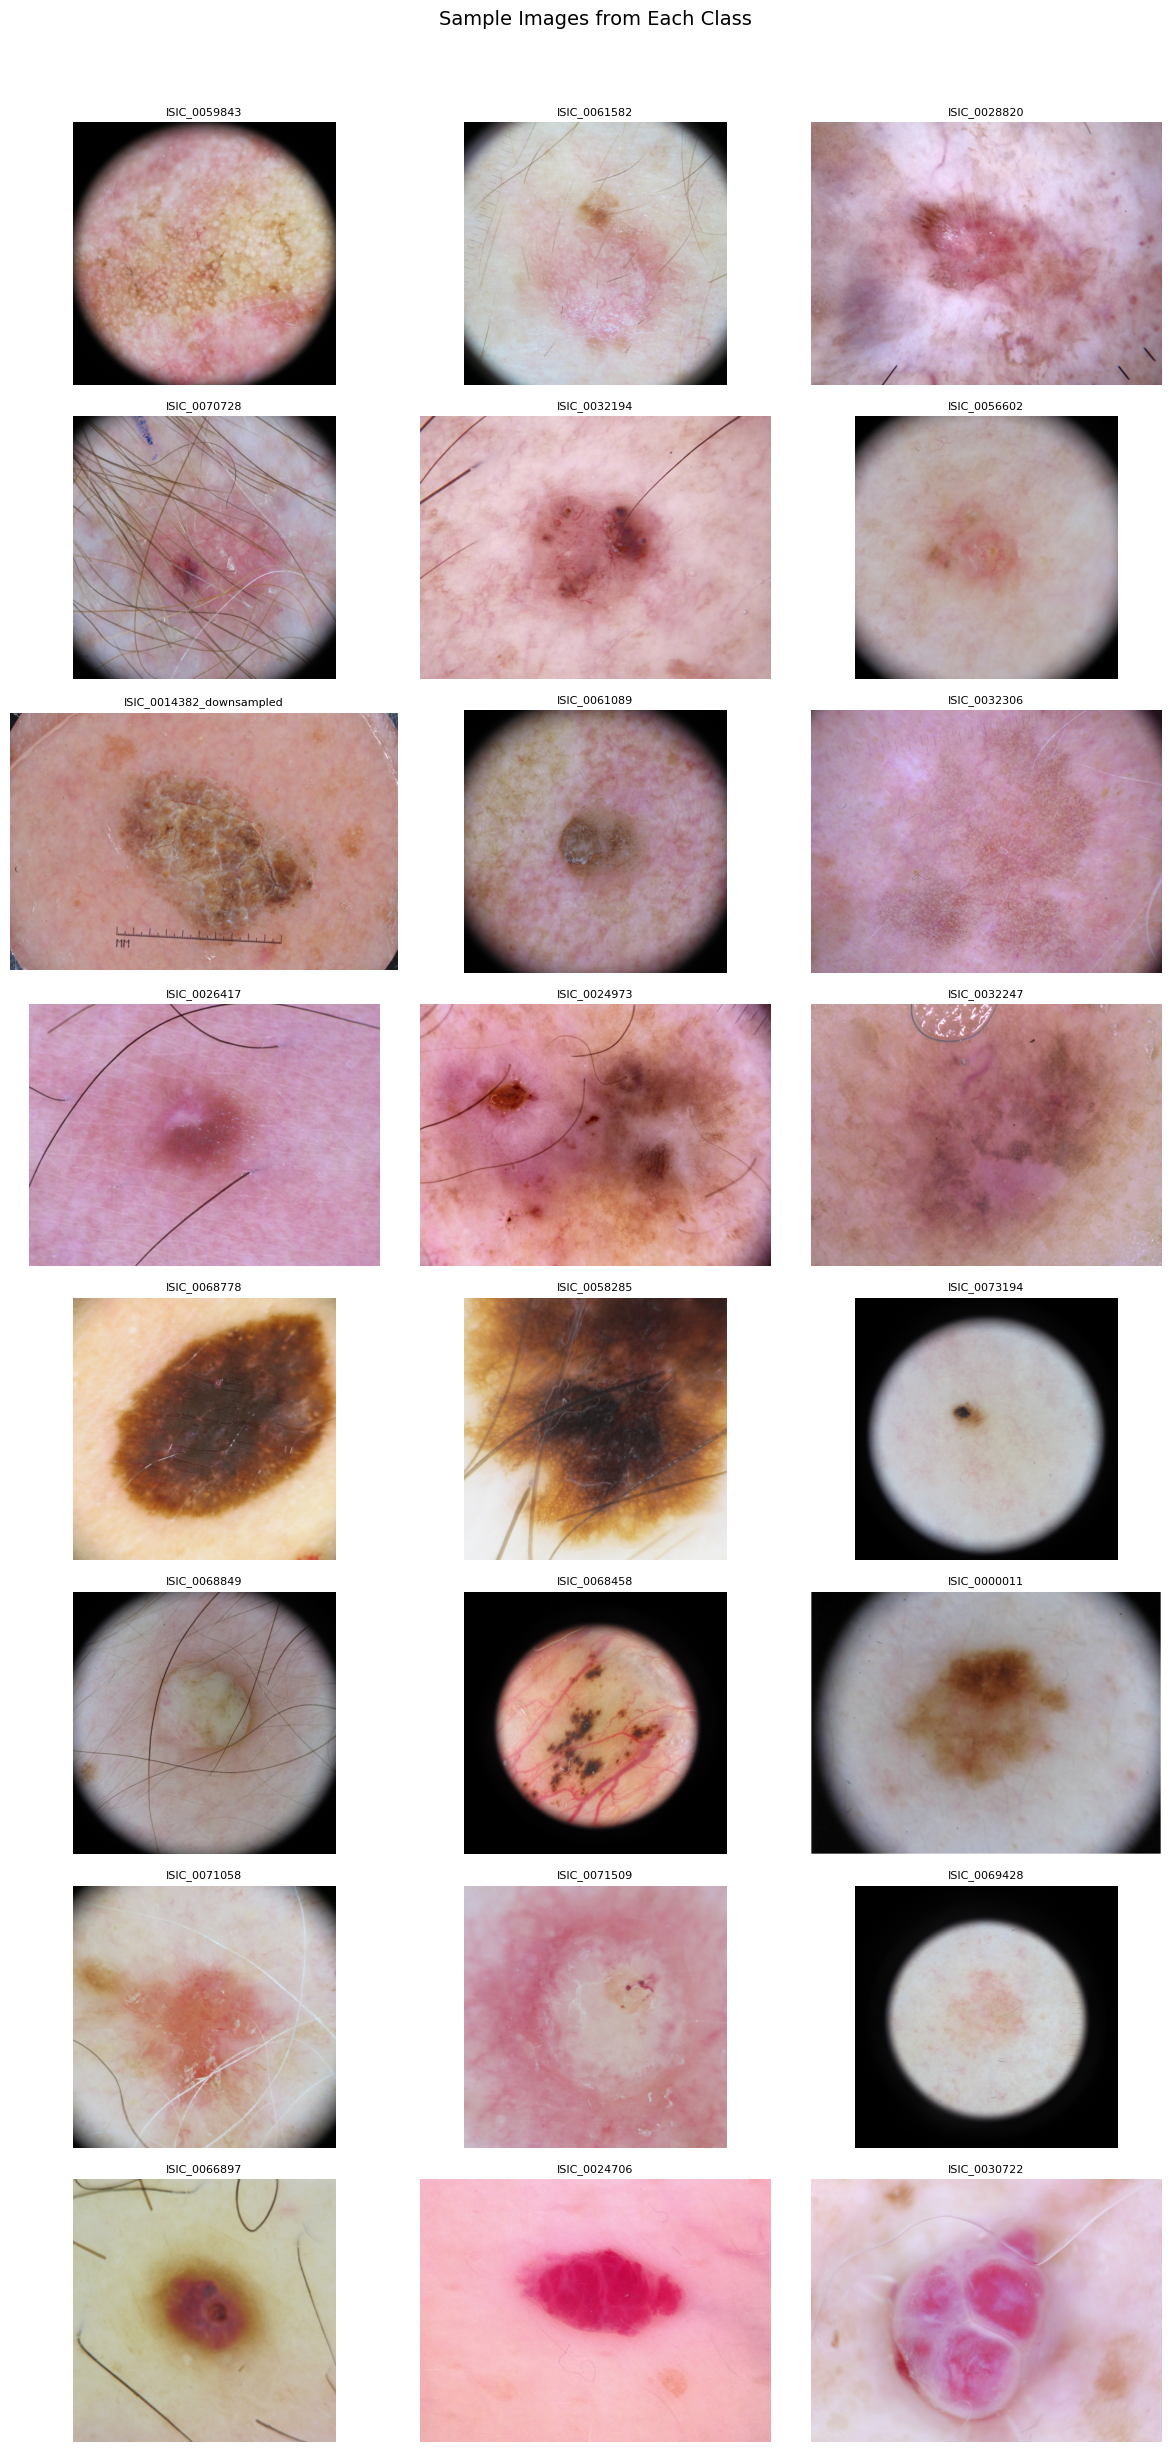

In [9]:
class_names = sorted(df["class_label"].unique())
n_samples = 3
    
fig, axes = plt.subplots(len(class_names), n_samples, figsize=(12, 3*len(class_names)))
    
for i, class_name in enumerate(class_names):
    samples = load_sample_images(df, class_name, IMAGES_DIR, n_samples)
        
    for j, (img, name) in enumerate(samples):
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(class_name, fontsize=12, rotation=0, 
                                   labelpad=40, va="center")
        axes[i, j].set_title(name, fontsize=8)
    
plt.suptitle("Sample Images from Each Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_images_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


Visual inspection of samples reveals:
- Varying image sizes and aspect ratios across samples
- Different lighting conditions and color profiles
- Some images contain hair and other artifacts
- Lesion sizes vary significantly within the frame

These observations inform our preprocessing pipeline requirements.

In [10]:
class_descriptions = {
    "AK": "Actinic Keratosis - rough, scaly patch; precancerous",
    "BCC": "Basal Cell Carcinoma - most common skin cancer; slow-growing",
    "BKL": "Benign Keratosis - non-cancerous growths",
    "DF": "Dermatofibroma - benign fibrous nodule",
    "MEL": "Melanoma - most dangerous skin cancer; irregular borders",
    "NV": "Melanocytic Nevus - common mole; benign",
    "SCC": "Squamous Cell Carcinoma - second most common skin cancer",
    "VASC": "Vascular Lesion - blood vessel abnormalities"
}

print("Lesion Type Descriptions:")
for cls, desc in class_descriptions.items():
    count = class_counts.get(cls, 0)
    print(f"\n{cls} (n={count}):")
    print(f"  {desc}")

Lesion Type Descriptions:

AK (n=867):
  Actinic Keratosis - rough, scaly patch; precancerous

BCC (n=3323):
  Basal Cell Carcinoma - most common skin cancer; slow-growing

BKL (n=2624):
  Benign Keratosis - non-cancerous growths

DF (n=239):
  Dermatofibroma - benign fibrous nodule

MEL (n=4522):
  Melanoma - most dangerous skin cancer; irregular borders

NV (n=12875):
  Melanocytic Nevus - common mole; benign

SCC (n=628):
  Squamous Cell Carcinoma - second most common skin cancer

VASC (n=253):
  Vascular Lesion - blood vessel abnormalities


In [11]:
benign_classes = ["NV", "BKL", "DF", "VASC"]
malignant_classes = ["MEL", "BCC", "SCC"]
precancerous_classes = ["AK"]

benign_count = sum(class_counts.get(c, 0) for c in benign_classes)
malignant_count = sum(class_counts.get(c, 0) for c in malignant_classes)
precancerous_count = sum(class_counts.get(c, 0) for c in precancerous_classes)

print("Binary Classification Perspective:")
print(f"Benign: {benign_count} ({benign_count/len(df)*100:.1f}%)")
print(f"Malignant: {malignant_count} ({malignant_count/len(df)*100:.1f}%)")
print(f"Precancerous: {precancerous_count} ({precancerous_count/len(df)*100:.1f}%)")

Binary Classification Perspective:
Benign: 15991 (63.1%)
Malignant: 8473 (33.4%)
Precancerous: 867 (3.4%)


From a clinical perspective, benign lesions significantly outnumber malignant ones. However, correctly identifying malignant cases (MEL, BCC, SCC) is critical for patient outcomes.

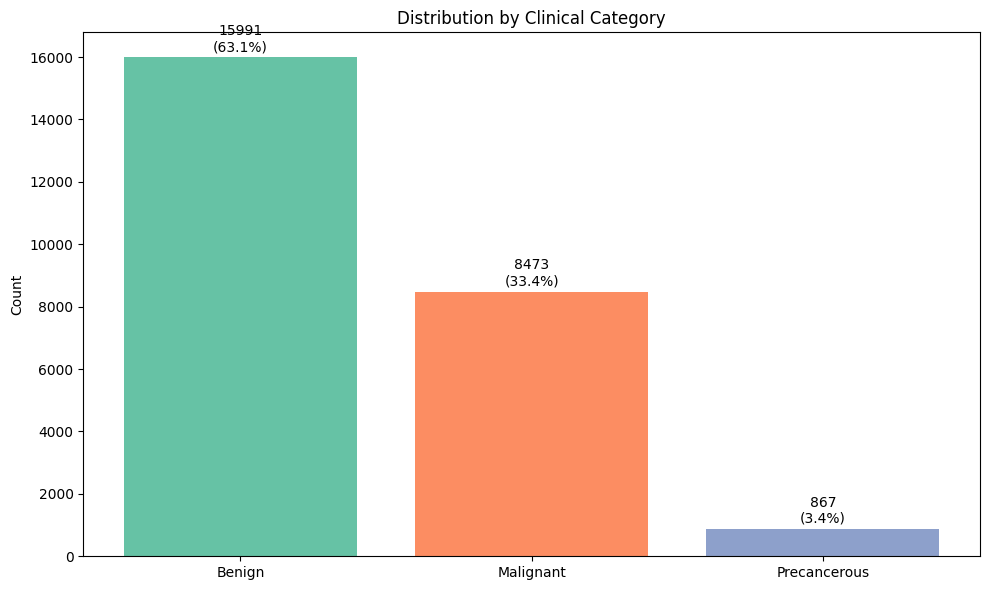

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

category_counts = pd.Series({
    "Benign": benign_count,
    "Malignant": malignant_count,
    "Precancerous": precancerous_count
})

colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
bars = ax.bar(category_counts.index, category_counts.values, color=colors)

ax.set_ylabel("Count")
ax.set_title("Distribution by Clinical Category")

for bar, count in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f"{count}\n({count/len(df)*100:.1f}%)", 
            ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "clinical_category_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
eda_summary = {
    "total_samples": len(df),
    "num_classes": len(class_counts),
    "class_counts": {k: int(v) for k, v in class_counts.items()},
    "imbalance_ratio": float(imbalance_ratio),
    "majority_class": class_counts.idxmax(),
    "minority_class": class_counts.idxmin(),
    "benign_count": int(benign_count),
    "malignant_count": int(malignant_count),
    "precancerous_count": int(precancerous_count)
}

with open(RESULTS_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2)
    
print("EDA summary saved.")

EDA summary saved.
